# Análisis Exploratorio de precios de combustible en Colombia

## Objetivo
Analizar el nivel y la variabilidad de los precios según la marca.

#Importación de Librerías

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Carga de datos

In [ ]:
import pandas as pd

url = ("https://www.datos.gov.co/resource/x6id-4v3g.csv?$limit=13574")
df = pd.read_csv(url)
df.head()

,departamentocodigo,departamentonombre,municipiocodigo,municipionombre,agente,bandera,direccion,producto,precio,estado,fecharegistro
0,63,QUINDIO,63001,ARMENIA,ESTACION DE SERVICIO AUTOMOTRIZ TERPEL CENTENARIO,TERPEL,CARRERA 18 # 45 - 55,BIODIESEL EXTRA,8190,1,2015-01-02T00:00:00.000
1,63,QUINDIO,63001,ARMENIA,ESTACION DE SERVICIO AUTOMOTRIZ TERPEL CENTENARIO,TERPEL,CARRERA 18 # 45 - 55,GASOLINA CORRIENTE OXIGENADA,8140,1,2015-01-02T00:00:00.000
2,27,CHOCO,27430,MEDIO BAUDO (PUERTO MELUK),ESTACION DE SERVICIO AUTOMOTRIZ JZ No 2,TERPEL,PUERTO MELUK CABECERA MUNICIPAL,KEROSENE,9100,1,2015-01-02T00:00:00.000
3,63,QUINDIO,63001,ARMENIA,ESTACION DE SERVICIO AUTOMOTRIZ TERPEL CENTENARIO,TERPEL,CARRERA 18 # 45 - 55,GASOLINA EXTRA OXIGENADA,10370,1,2015-01-02T00:00:00.000
4,27,CHOCO,27430,MEDIO BAUDO (PUERTO MELUK),ESTACION DE SERVICIO AUTOMOTRIZ JZ No 2,TERPEL,PUERTO MELUK CABECERA MUNICIPAL,GASOLINA CORRIENTE OXIGENADA,9100,1,2015-01-02T00:00:00.000


#Exploración inicial

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13574 entries, 0 to 13573
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   departamentocodigo  13574 non-null  int64 
 1   departamentonombre  13574 non-null  object
 2   municipiocodigo     13574 non-null  int64 
 3   municipionombre     13574 non-null  object
 4   agente              13574 non-null  object
 5   bandera             13574 non-null  object
 6   direccion           13574 non-null  object
 7   producto            13574 non-null  object
 8   precio              13574 non-null  int64 
 9   estado              13574 non-null  int64 
 10  fecharegistro       13574 non-null  object
dtypes: int64(4), object(7)
memory usage: 1.1+ MB


In [ ]:
df.describe()

,departamentocodigo,municipiocodigo,precio,estado
count,13574.000000,13574.000000,13574.000000,13574.0
mean,36.861942,37163.900840,8723.510609,1.0
std,26.381426,26390.415588,1349.255290,0.0
min,5.000000,5001.000000,1000.000000,1.0
25%,13.000000,13140.000000,8135.000000,1.0
50%,25.000000,25718.000000,8620.000000,1.0
75%,54.000000,54820.000000,9140.000000,1.0
max,99.000000,99773.000000,20000.000000,1.0


#Calidad de los datos

In [ ]:
df.isnull().sum()

,0
departamentocodigo,0
departamentonombre,0
municipiocodigo,0
municipionombre,0
agente,0
bandera,0
direccion,0
producto,0
precio,0
estado,0


In [ ]:
duplicados = df.duplicated().sum()
print(f"Cantidad de registros duplicados: {duplicados}")

Cantidad de registros duplicados: 0


# 2. Limpieza

In [ ]:
#Convertir fecha
df['fecharegistro'] = pd.to_datetime(df['fecharegistro'])

df['precio'] = df['precio'].astype(float)

df.dtypes

,0
departamentocodigo,int64
departamentonombre,object
municipiocodigo,int64
municipionombre,object
agente,object
bandera,object
direccion,object
producto,object
precio,float64
estado,int64


In [ ]:
!pip install ydata-profiling
from ydata_profiling import ProfileReport

profile = ProfileReport(df)
profile.to_file("reporte.html")
profile

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 400.8/400.8 kB 8.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.7/296.7 kB 21.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 63.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 679.7/679.7 kB 36.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 105.4/105.4 kB 7.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.0/72.0 kB 5.1 MB/s eta 0:00:00


/tmp/ipykernel_2042/642472594.py:2: DeprecationWarning: 
    `import ydata_profiling` is deprecated and will not receive more updates. 
    Please install fg-data-profiling via `pip install fg-data-profiling` and use `import data_profiling` instead.
    
  from ydata_profiling import ProfileReport


Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|██████████| 11/11 [00:00<00:00, 30.46it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

#Análisis

In [ ]:
#Por marca
df.groupby('bandera')['precio'].mean().sort_values(ascending=False)

,precio
bandera,
GULF,9480.000000
PROXXON,9399.142857
TEXACO,9128.342558
BRIO,9128.309524
ESSO,9112.096774
MOBIL,9111.585242
ZEUSS,9107.881007
ZAPATA Y VELASQUEZ,8992.346939
CASAMOTOR,8980.965909


In [ ]:
#Variabilidad por marca
df.groupby('bandera')['precio'].std().sort_values(ascending=False)

,precio
bandera,
GULF,1615.580391
MOBIL,1389.007495
ESSO,1360.264840
TEXACO,1331.599185
TERPEL,1304.239058
PUMA,1294.670658
ECOS,1203.763356
PROXXON,1183.311186
PETROMIL,1168.417109


In [ ]:
#Por producto
df.groupby('producto')['precio'].mean().sort_values(ascending=False)

,precio
producto,
GASOLINA EXTRA OXIGENADA,11293.263001
GASOLINA EXTRA,10314.000000
GASOLINA CORRIENTE OXIGENADA,8632.966547
BIOACEM AL 9%,8456.633568
KEROSENE,8208.000000
BIODIESEL EXTRA,8116.881798
BIODIESEL CORRIENTE,7724.937500
ACPM - DIESEL,7230.000000
GASOLINA CORRIENTE,7198.240000


In [ ]:
#Temporal
df['mes'] = df['fecharegistro'].dt.to_period('M')
df.groupby('mes')['precio'].mean().sort_values(ascending=False)

,precio
mes,
2015-03,10008.500000
2016-05,9170.454545
2016-01,9000.000000
2015-02,8785.533333
2015-01,8784.416667
2018-05,8756.769057
2017-12,8748.250000
2018-04,8746.193694
2018-03,8740.801802


#Gráficos

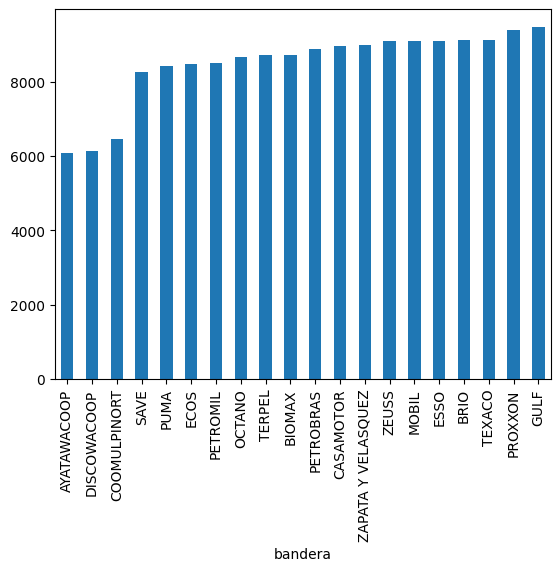

In [ ]:
df.groupby('bandera')['precio'].mean().sort_values().plot(kind='bar')
plt.show()

#Correlación

In [ ]:
df.corr(numeric_only=True)

,departamentocodigo,municipiocodigo,precio,estado
departamentocodigo,1.000000,0.999937,-0.103363,NaN
municipiocodigo,0.999937,1.000000,-0.104731,NaN
precio,-0.103363,-0.104731,1.000000,NaN
estado,NaN,NaN,NaN,NaN


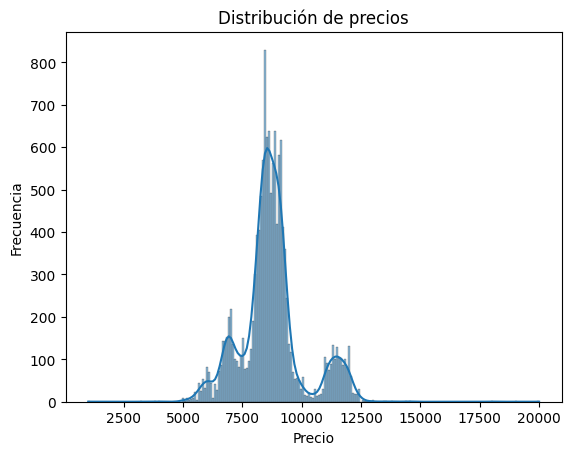

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(df['precio'], kde=True)
plt.title('Distribución de precios')
plt.xlabel('Precio')
plt.ylabel('Frecuencia')
plt.show()

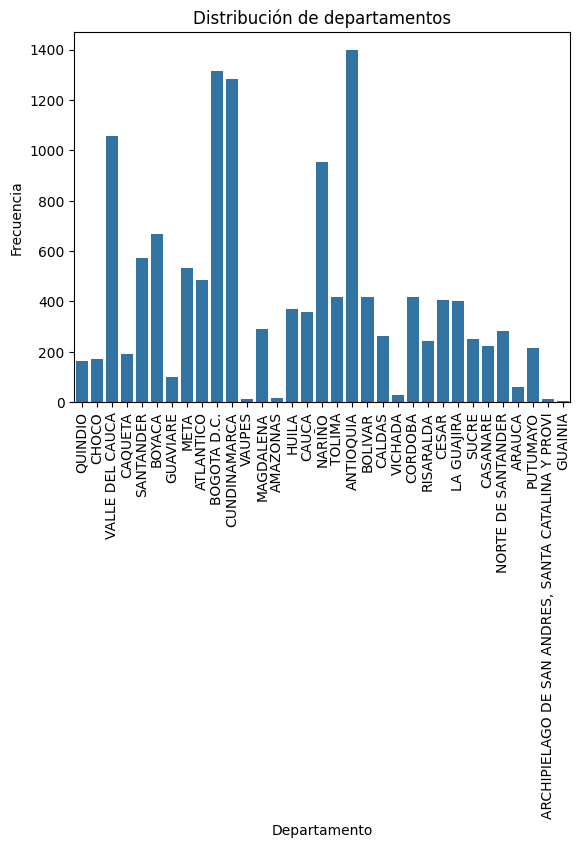

In [ ]:
sns.countplot(x='departamentonombre', data=df)
plt.title('Distribución de departamentos')
plt.xlabel('Departamento')
plt.ylabel('Frecuencia')
plt.xticks(rotation=90)
plt.show()

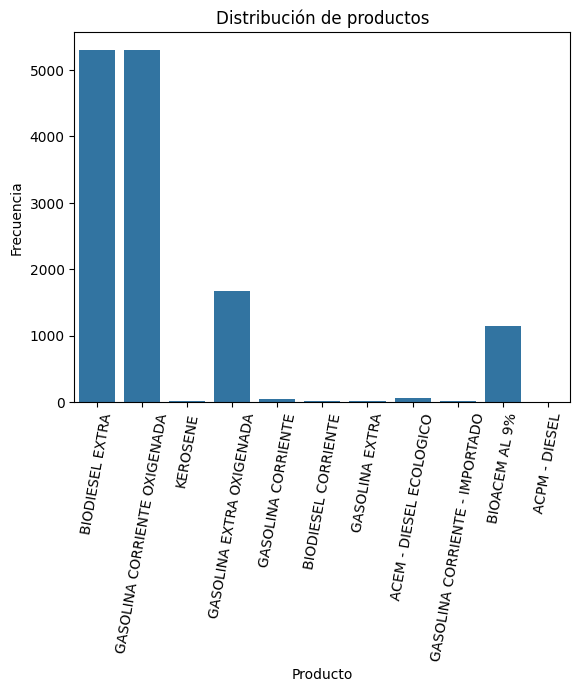

In [ ]:
sns.countplot(x='producto', data=df)
plt.title('Distribución de productos')
plt.xlabel('Producto')
plt.ylabel('Frecuencia')
plt.xticks(rotation=80)
plt.show()

# resumen estadistico

In [ ]:
#Variables númericas
display (df.describe())

,departamentocodigo,municipiocodigo,precio,estado,fecharegistro
count,13574.000000,13574.000000,13574.000000,13574.0,13574
mean,36.861942,37163.900840,8723.510609,1.0,2018-04-10 05:58:08.610579200
min,5.000000,5001.000000,1000.000000,1.0,2015-01-02 00:00:00
25%,13.000000,13140.000000,8135.000000,1.0,2018-05-02 00:00:00
50%,25.000000,25718.000000,8620.000000,1.0,2018-05-02 00:00:00
75%,54.000000,54820.000000,9140.000000,1.0,2018-05-04 00:00:00
max,99.000000,99773.000000,20000.000000,1.0,2018-05-13 00:00:00
std,26.381426,26390.415588,1349.255290,0.0,NaN


In [ ]:
#Variables cátegoricas
display (df.describe(include='object'))

,departamentonombre,municipionombre,agente,bandera,direccion,producto
count,13574,13574,13574,13574,13574,13574
unique,33,903,5253,20,5381,11
top,ANTIOQUIA,BOGOTA D.C.,ESTACION DE SERVICIO SAN ANTONIO,TERPEL,VEREDA CODEMACO,BIODIESEL EXTRA
freq,1398,1313,16,4928,12,5296
